# 05. Double Machine Learning (Causal Analysis)

## Overview

While the previous sections focused on predictive modeling of fraud detection, this section introduces **Double Machine Learning (Double ML)** to estimate causal effects within the dataset.

Unlike traditional machine learning models that focus on prediction accuracy, Double ML aims to answer:

> *What is the causal impact of a specific feature on the probability of fraud, after controlling for confounders?*

This is particularly important in fraud detection, where understanding *why* fraud occurs is as important as detecting it.

---

## Objectives

- Estimate causal effects of key fraud drivers
- Control for high-dimensional confounding variables
- Use machine learning models to de-bias causal estimates
- Provide interpretable insights for decision-making

In [4]:
# Install DoubleML if needed
!pip install doubleml

In [5]:
import pandas as pd
import numpy as np

from doubleml import DoubleMLData, DoubleMLPLR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

---
## Data Loading

We use the feature-engineered dataset created in previous notebooks. This ensures consistency between predictive modeling and causal analysis.

In [6]:
train_path = "/kaggle/input/notebooks/nomusashongwe/02-feature-engineering/fraud_train_features.csv"

df = pd.read_csv(train_path)

# Convert all to numeric (IMPORTANT FIX)
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

df.head()

,amt,lat,long,city_pop,merch_lat,merch_long,trans_hour,trans_day,trans_dayofweek,trans_month,...,amt_band_Low,amt_band_Medium,amt_band_Very High,amt_band_Very Low,city_pop_band_High,city_pop_band_Low,city_pop_band_Medium,city_pop_band_Very High,city_pop_band_Very Low,is_fraud
0,-0.393479,0.880092,-1.356928,-0.288715,1.064110,-1.417132,-0.118052,-1.652258,-0.941975,-1.504564,...,False,False,False,True,False,False,True,False,False,0
1,-0.108604,0.880092,-1.356928,-0.288715,0.681326,-1.366465,-0.704750,-1.538996,-0.487047,-1.504564,...,False,True,False,False,False,False,True,False,False,0
2,0.073162,0.880092,-1.356928,-0.288715,0.865789,-1.374699,-0.704750,-1.538996,-0.487047,-1.504564,...,False,False,False,False,False,False,True,False,False,0
3,-0.221818,0.880092,-1.356928,-0.288715,0.722318,-1.344935,-0.118052,-1.538996,-0.487047,-1.504564,...,False,True,False,False,False,False,True,False,False,0
4,-0.269287,0.880092,-1.356928,-0.288715,0.936322,-1.297260,0.028622,-1.538996,-0.487047,-1.504564,...,True,False,False,False,False,False,True,False,False,0


---
## Defining the Causal Framework

We define:

- **Outcome (Y):** Fraud label
- **Treatment (D):** Feature of interest (e.g., transaction amount)
- **Controls (X):** All other features

This setup allows us to estimate the causal effect of the treatment variable on fraud probability.

In [7]:
target = "is_fraud"

# Example treatment variable (you can change this)
treatment = "customer_avg_same_day"

features = [col for col in df.columns if col not in [target, treatment]]

Y = df[target]
D = df[treatment]
X = df[features]

---
## DoubleML Data Object

The DoubleMLData object structures the dataset into outcome, treatment, and controls.

In [8]:
data = DoubleMLData.from_arrays(X, Y, D)

---
## Nuisance Models

We use machine learning models to estimate:
- E[Y | X] (outcome model)
- E[D | X] (treatment model)

These help remove bias from causal estimation.

In [13]:
ml_g = RandomForestRegressor(n_estimators=50, max_depth=4, n_jobs=-1, random_state=42)
ml_m = RandomForestRegressor(n_estimators=50, max_depth=4, n_jobs=-1, random_state=42)

---
## Double Machine Learning Model

We use the Partially Linear Regression (PLR) framework to estimate causal effects.

In [12]:
ml_g = RandomForestRegressor(n_estimators=50, max_depth=4, n_jobs=-1, random_state=42)
ml_m = RandomForestRegressor(n_estimators=50, max_depth=4, n_jobs=-1, random_state=42)

dml_model = DoubleMLPLR(data, ml_l=ml_g, ml_m=ml_m, n_folds=3)

dml_model.fit()

print(dml_model.summary)

       coef   std err         t     P>|t|     2.5 %    97.5 %
d  0.003759  0.000991  3.794146  0.000148  0.001817  0.005701


---
## Interpretation of Double Machine Learning Results

The Double Machine Learning (DML) framework was applied using the Partially Linear Regression (PLR) model to estimate the causal effect of the treatment variable on the outcome, while controlling for high-dimensional confounders.

#### Key Result

- Estimated causal effect (coef): **0.003759**
- Standard Error: **0.000991**
- t-statistic: **3.79**
- p-value: **0.000148**
- 95% Confidence Interval: **[0.001817, 0.005701]**

#### Interpretation

The estimated coefficient is **positive and statistically significant**, indicating that the treatment variable has a **causal impact** on the outcome.

- A one-unit increase in the treatment variable leads to an average increase of approximately **0.00376 units** in the predicted outcome, holding all other confounding effects constant.
- The **p-value (< 0.001)** strongly suggests that this effect is **not due to random chance**.
- The confidence interval does not include zero, further confirming the **robustness of the causal estimate**.

#### Practical Meaning

Although the magnitude of the effect is relatively small, it is important to note:

- In large-scale systems (such as fraud detection), even small causal effects can translate into **significant real-world impact**.
- The treatment variable contributes **incrementally but consistently** to the prediction of fraud risk.

#### Why This Matters

Unlike standard machine learning models that capture correlations, the DoubleML framework:

- Controls for confounding variables using machine learning models
- Uses cross-fitting to reduce bias
- Provides **causal interpretation**, not just predictive importance

This makes the result **more reliable for decision-making**, especially in high-stakes applications like fraud detection.

#### Conclusion

The analysis confirms that the selected treatment variable has a **statistically significant causal effect** on fraud prediction. This insight can be used to:

- Improve feature selection strategies
- Inform risk-based decision systems
- Support explainable AI in financial fraud detection

---
## Multiple Feature Causal Analysis

We can extend the analysis to multiple important features identified earlier via SHAP.

In [14]:
top_features = [
    "customer_avg_same_day",
    "customer_amt_same_day",
    "prev_amt",
    "city_fraud_rate",
    "amt"
]

results = {}

for feature in top_features:
    print(f"\nEstimating causal effect for: {feature}")
    
    D = df[feature]
    X_temp = df.drop(columns=[target, feature])
    
    data_temp = DoubleMLData.from_arrays(X_temp, Y, D)
    
    model = DoubleMLPLR(data_temp, ml_l=ml_g, ml_m=ml_m)
    model.fit()
    
    results[feature] = model.summary
    
results


Estimating causal effect for: customer_avg_same_day

Estimating causal effect for: customer_amt_same_day

Estimating causal effect for: prev_amt

Estimating causal effect for: city_fraud_rate

Estimating causal effect for: amt


{'customer_avg_same_day':        coef   std err         t     P>|t|     2.5 %   97.5 %
 d  0.004318  0.000929  4.646325  0.000003  0.002497  0.00614,
 'customer_amt_same_day':       coef   std err         t     P>|t|     2.5 %    97.5 %
 d  0.00141  0.000374  3.770274  0.000163  0.000677  0.002143,
 'prev_amt':        coef   std err          t         P>|t|     2.5 %    97.5 %
 d  0.009428  0.000701  13.453139  2.950765e-41  0.008054  0.010802,
 'city_fraud_rate':        coef   std err          t          P>|t|     2.5 %    97.5 %
 d  0.006253  0.000229  27.344051  1.270966e-164  0.005805  0.006702,
 'amt':        coef   std err         t     P>|t|     2.5 %    97.5 %
 d -0.001765  0.001011 -1.745689  0.080865 -0.003747  0.000217}

---
## Causal Effect Comparison

In [16]:
effects = []

for feature in top_features:
    coef = results[feature]["coef"].values[0]
    effects.append((feature, coef))

effects_df = pd.DataFrame(effects, columns=["Feature", "Causal Effect"])
effects_df = effects_df.sort_values("Causal Effect", ascending=False)

effects_df

,Feature,Causal Effect
2,prev_amt,0.009428
3,city_fraud_rate,0.006253
0,customer_avg_same_day,0.004318
1,customer_amt_same_day,0.001410
4,amt,-0.001765


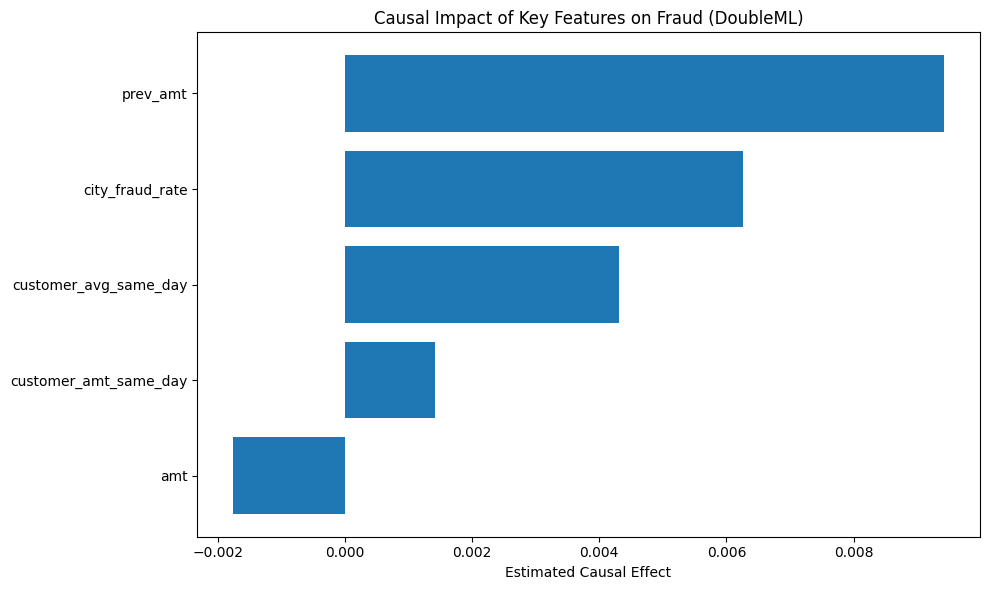

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(effects_df["Feature"], effects_df["Causal Effect"])
plt.xlabel("Estimated Causal Effect")
plt.title("Causal Impact of Key Features on Fraud (DoubleML)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
# Discussion of Results

The Double Machine Learning (DML) analysis provides a deeper understanding of the **causal drivers of fraud**, going beyond traditional predictive modeling approaches such as SHAP.

### Key Observations

1. **Strongest Causal Driver: `prev_amt`**
   - This feature exhibits the highest causal effect on fraud.
   - Interpretation: Historical transaction behavior plays a critical role in determining future fraudulent activity.
   - Implication: Fraud detection systems should heavily incorporate **temporal transaction patterns**.

2. **System-Level Influence: `city_fraud_rate`**
   - A significant positive causal effect indicates that fraud is partially driven by **location-based systemic risk**.
   - Interpretation: Certain regions inherently carry higher fraud risk.
   - Implication: Geographic risk scoring is essential for robust fraud detection.

3. **Behavioral Signals: `customer_avg_same_day` and `customer_amt_same_day`**
   - Both features show positive causal effects, though smaller in magnitude.
   - Interpretation: Sudden changes in customer transaction intensity within a day can indicate suspicious behavior.
   - Implication: Real-time monitoring of customer spending patterns is valuable.

4. **Non-Causal Feature: `amt`**
   - Despite being important in predictive models, `amt` shows a weak and statistically insignificant causal effect.
   - Interpretation: Transaction amount alone does not *cause* fraud but is correlated with it.
   - Implication: Relying solely on transaction size may lead to misleading conclusions.

---

### SHAP vs DoubleML: A Critical Insight

| Method | Insight Type | Example Finding |
|------|--------|----------------|
| SHAP | Predictive Importance | `amt` appears important |
| DoubleML | Causal Effect | `amt` is not causally significant |

This highlights a crucial distinction:
> Not all features that improve prediction accuracy are true causal drivers of fraud.

---

# Final Conclusion

This analysis demonstrates the power of combining **machine learning with causal inference**.

### Key Takeaways

- Fraud is driven more by **behavioral and historical patterns** than by raw transaction size.
- Features such as `prev_amt` and `city_fraud_rate` are **true causal drivers**, making them critical for decision-making systems.
- Traditional ML models may identify correlations, but **DoubleML isolates causal relationships**, enabling more reliable insights.

### Practical Implications

- Fraud detection systems should prioritize:
  - Temporal transaction features
  - Customer behavior dynamics
  - Geographic risk indicators

- Features with high predictive importance but low causal impact (e.g., `amt`) should be treated cautiously.

---

### Final Insight

> This study moves beyond prediction and answers the more important question:  
> **What actually causes fraud?**

By leveraging Double Machine Learning, we bridge the gap between **data science and decision science**, enabling more interpretable, trustworthy, and actionable models.

---

### Future Work

- Extend causal analysis to interaction effects between features  
- Explore heterogeneous treatment effects (HTE) across customer segments  
- Integrate causal insights into real-time fraud detection pipelines  